In [1]:
from pathlib import Path

DATASET_PATH = "./Sign Language Detection/dataset_split"
root = Path(DATASET_PATH)
assert root.exists(), f"Dataset path not found: {DATASET_PATH}. Change DATASET_PATH to correct folder."
print(root)

Sign Language Detection\dataset_split


In [2]:
train_images = root / "images" / "train"
train_labels = root / "labels" / "train"

test_images = root / "images" / "test"
test_labels = root / "labels" / "test"

print("Train images path:", train_images)
print("Train labels path:", train_labels)

Train images path: Sign Language Detection\dataset_split\images\train
Train labels path: Sign Language Detection\dataset_split\labels\train


Wytrenowany model do detekcji współrzędnych dłoni

In [3]:
import tensorflow as tf

# Wczytanie modelu
hand_detector = tf.keras.models.load_model('hand_detector_best.keras')
hand_detector

d:\Magisterka\Semestr 3\Uczenie Glebokie L\hand-sign-recognition\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


<Functional name=functional_3, built=True>

In [4]:
for p in [train_images, train_labels]:
    if not p.exists():
        print("Warning: path not found ->", p)

print("Train images:", len(list(train_images.glob("*.*"))))

Train images: 87


Showing sample: IMG_7273.JPG


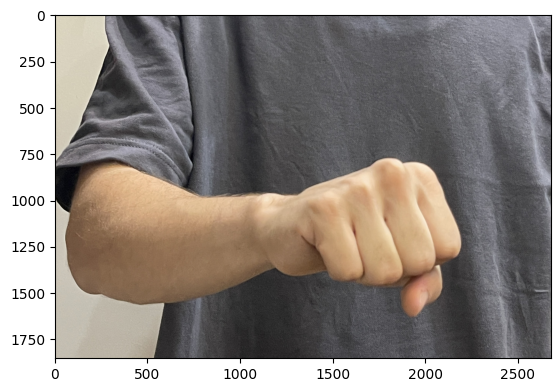

In [5]:
import matplotlib.pyplot as plt

# show one sample (if exists)
sample_imgs = list(train_images.glob("*.*"))
if sample_imgs:
    sample_img = sample_imgs[0]
    sample_label = train_labels / (sample_img.stem + ".txt")
    print("Showing sample:", sample_img.name)
    plt.imshow(plt.imread(sample_img))
else:
    print("No images found in train/images.")

In [6]:
IMG_SIZE = 512

In [7]:
NUMBER_OF_CLASSES = 5

In [9]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Zakładamy, że detektor był trenowany na 224x224 (zgodnie z naszą poprzednią rozmową)
DETECTOR_SIZE = (224, 224) 

def load_data_with_detection(img_dir, label_dir, detector_model):
    images = []
    labels = []
    
    img_files = sorted(list(img_dir.glob("*.*")))
    
    print(f"Przetwarzanie {len(img_files)} obrazów z detekcją dłoni...")

    for i, img_path in enumerate(img_files):
        # 1. Wczytanie oryginalnego obrazu
        # Używamy imread z flagą, by upewnić się, że wczytuje 3 kanały
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None: continue
        
        h_orig, w_orig, _ = img_bgr.shape
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # ---------------------------------------------------------
        # ETAP 1: DETEKCJA (Szukamy dłoni)
        # ---------------------------------------------------------
        
        # Przygotowanie pod detektor (Resize do 224x224 + Normalizacja)
        input_for_detector = cv2.resize(img_rgb, DETECTOR_SIZE) / 255.0
        input_for_detector = np.expand_dims(input_for_detector, axis=0) # Dodanie wymiaru batcha [1, 224, 224, 3]

        # Predykcja ramki [x, y, w, h] (wartości 0.0 - 1.0)
        box_norm = detector_model.predict(input_for_detector, verbose=0)[0]
        
        # Konwersja na piksele
        x = int(box_norm[0] * w_orig)
        y = int(box_norm[1] * h_orig)
        w = int(box_norm[2] * w_orig)
        h = int(box_norm[3] * h_orig)

        # Dodajemy margines (padding), żeby nie uciąć palców
        padding = 20
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(w_orig - x, w + 2 * padding)
        h = min(h_orig - y, h + 2 * padding)

        # Wycięcie dłoni (Crop)
        hand_crop = img_rgb[y:y+h, x:x+w]

        # Zabezpieczenie: jeśli detektor zwrócił bzdury i crop jest pusty (0x0), bierzemy oryginał
        if hand_crop.size == 0:
            hand_crop = img_rgb

        # ---------------------------------------------------------
        # ETAP 2: PRZYGOTOWANIE POD KLASYFIKATOR
        # ---------------------------------------------------------
        
        # Resize wycinka do rozmiaru docelowego klasyfikatora (IMG_SIZE)
        hand_crop_resized = cv2.resize(hand_crop, (IMG_SIZE, IMG_SIZE))
        images.append(hand_crop_resized)
        
        # Wczytanie etykiety (bez zmian)
        label_path = label_dir / (img_path.stem + ".txt")
        if label_path.exists():
            with open(label_path, 'r') as f:
                first_line = f.readline().split()
                if first_line:
                    labels.append(int(first_line[0]))
        else:
            labels.append(0)
            
        # Opcjonalnie: Pokaż postęp co 100 zdjęć
        if i % 100 == 0:
            print(f"Przetworzono {i}/{len(img_files)}")

    print("Zakończono wczytywanie.")
    return np.array(images) / 255.0, to_categorical(np.array(labels), num_classes=NUMBER_OF_CLASSES)

In [22]:
X_train, y_train = load_data_with_detection(train_images, train_labels, hand_detector)

Przetwarzanie 87 obrazów z detekcją dłoni...
Przetworzono 0/87
Zakończono wczytywanie.


In [13]:
X_train.shape

(87, 512, 512, 3)

In [14]:
X_test, y_test = load_data_with_detection(test_images, test_labels, hand_detector)

Przetwarzanie 13 obrazów z detekcją dłoni...
Przetworzono 0/13
Zakończono wczytywanie.


In [15]:
from keras import backend as K

print(K.image_data_format())

channels_last


In [16]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Pierwsza warstwa splotowa - wyciąga krawędzie i proste wzory
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Druga warstwa - bardziej złożone kształty dłoni
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Trzecia warstwa
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Spłaszczenie danych do warstw gęstych (klasyfikatora)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Zapobiega przeuczeniu
    layers.Dense(NUMBER_OF_CLASSES, activation='softmax') # 5 wyjść (dla każdej klasy znaku)
])

model.summary()

d:\Magisterka\Semestr 3\Uczenie Glebokie L\hand-sign-recognition\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 510, 510, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 492032)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    62,980,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,074,117 (240.61 MB)

 Trainable params: 63,074,117 (240.61 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [24]:
# Callbacks - Zatrzymanie treningu, gdy model przestanie się uczyć
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')
]

In [26]:
# Start treningu
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.2874 - loss: 34.4453 - val_accuracy: 0.1538 - val_loss: 9.7026 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 981ms/step - accuracy: 0.1494 - loss: 9.8853 - val_accuracy: 0.0769 - val_loss: 2.6224 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 990ms/step - accuracy: 0.2184 - loss: 2.1870 - val_accuracy: 0.1538 - val_loss: 1.6435 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 952ms/step - accuracy: 0.2529 - loss: 1.5918 - val_accuracy: 0.1538 - val_loss: 1.6585 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 977ms/step - accuracy: 0.2069 - loss: 1.5995 - val_accuracy: 0.2308 - val_loss: 1.5906 - learning_rate: 0.0010
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 961ms/step - accuracy: 0.3563 - loss: 1.5551 - val_accuracy: 0.2308 - val_loss: 1.5520 - learning_rate: 0.0010
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 962ms/step - accuracy: 0.3333 - loss: 1.5445 - val_accuracy: 0.

In [27]:
score = model.evaluate(X_test, y_test)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.6923 - loss: 0.6463
Test loss: 0.6463168859481812
Test accuracy: 0.692307710647583
